### Main Workflow

In [16]:
%load_ext autoreload
%autoreload 2

# load modules
import os, sys
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

# coastsat modules
sys.path.insert(0, os.pardir)
from coastsat import SDS_download, SDS_preprocess, SDS_shoreline, SDS_tools, SDS_classify

# EDA utils
import modified_coastsat # modifications for SWIR2 band
from indices import *
from thresholding import *
from spectral_plotting import (
    plot_indices, 
    plot_samples,
    plot_extractions,
    sample_ms,
    save_all_plots
)
from image_plotting_parameters import (
    get_image_plotting_params,
    fn_to_title,
)
import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
def save_all_sites(sitenames, output_epsgs, output_dir, index_funcs, thresh_funcs):

    for sitename, output_epsg in zip(sitenames, output_epsgs):
        print(f"{sitename}...")
        dl_dict, data_path, ref_sl, polygon = utils.init_site(sitename, output_epsg, output_dir)
        buffer_settings = {
            'output_epsg': output_epsg,
            'reference_shoreline': ref_sl,
            'max_dist_ref': 400,
            'min_length_sl': 500,
            'dist_clouds': 30,
        }
        metadata, inputs = utils.download(sitename, dl_dict, data_path, polygon)
        ims, cloud_masks, fns, georefs, im_buffers, im_nodatas, im_epsgs = utils.load_and_preprocess(metadata, inputs, buffer_settings)
        save_all_plots(sitename, fns, ims, cloud_masks, im_buffers, im_nodatas, georefs,
                    im_epsgs, index_funcs, thresh_funcs, buffer_settings, output_dir)

In [19]:
output_dir = "C:\\Users\\avanever\\Documents\\CoastSatProject\\Experiments"
sitenames = ["mini-rose-spit", "mini-island-view", "gas-cliff"]
output_epsgs = [3156, 3157, 3159]

utils.init_dir_structure(output_dir, "spectral_analysis")

You will need to fill the 'aoi' and 'ref_sl' directories with aoi kml from geojson.io and reference shoreline shapefiles corresponding to the sites

In [22]:
index_funcs = [
    mndwi,
    ndwi,
    awei_ns,
    awei_sh,
    scowi,
    wi2015,
    andwi,
    wri,
    ewi,
    nwi,
    wi2019
]
thresh_funcs = [
    otsu,
    local_min_otsu
]
save_all_sites(sitenames, output_epsgs, output_dir, index_funcs, thresh_funcs)

mini-rose-spit...
Reference shorelines found in GeoJSON. Loading coordinates for each feature.
GEE initialized (existing token).
Satellite images downloaded from GEE and save in C:\Users\avanever\Documents\CoastSatProject\Experiments\data\mini-rose-spit
GEE initialized (existing token).
Satellite images downloaded from GEE and save in C:\Users\avanever\Documents\CoastSatProject\Experiments\data\mini-rose-spit
GEE initialized (existing token).
Satellite images downloaded from GEE and save in C:\Users\avanever\Documents\CoastSatProject\Experiments\data\mini-rose-spit
GEE initialized (existing token).
Satellite images downloaded from GEE and save in C:\Users\avanever\Documents\CoastSatProject\Experiments\data\mini-rose-spit
GEE initialized (existing token).
Satellite images downloaded from GEE and save in C:\Users\avanever\Documents\CoastSatProject\Experiments\data\mini-rose-spit
GEE initialized (existing token).
Satellite images downloaded from GEE and save in C:\Users\avanever\Documents

### For Messing Around

In [3]:
output_dir = "C:\\Users\\avanever\\Documents\\CoastSatProject\\Experiments"
sitename = "mini-rose-spit"
output_epsg = 3156
dl_dict, data_path, ref_sl, polygon = utils.init_site(sitename, output_epsg, output_dir)

Reference shorelines found in GeoJSON. Loading coordinates for each feature.


In [4]:
metadata, inputs = utils.download(sitename, dl_dict, data_path, polygon)

GEE initialized (existing token).
Satellite images downloaded from GEE and save in C:\Users\avanever\Documents\CoastSatProject\Experiments\data\mini-rose-spit
GEE initialized (existing token).
Satellite images downloaded from GEE and save in C:\Users\avanever\Documents\CoastSatProject\Experiments\data\mini-rose-spit
GEE initialized (existing token).
Satellite images downloaded from GEE and save in C:\Users\avanever\Documents\CoastSatProject\Experiments\data\mini-rose-spit
GEE initialized (existing token).
Satellite images downloaded from GEE and save in C:\Users\avanever\Documents\CoastSatProject\Experiments\data\mini-rose-spit
GEE initialized (existing token).
Satellite images downloaded from GEE and save in C:\Users\avanever\Documents\CoastSatProject\Experiments\data\mini-rose-spit
GEE initialized (existing token).
Satellite images downloaded from GEE and save in C:\Users\avanever\Documents\CoastSatProject\Experiments\data\mini-rose-spit
GEE initialized (existing token).
Satellite im

In [5]:
buffer_settings = {
    'output_epsg': output_epsg,
    'reference_shoreline': ref_sl,
    'max_dist_ref': 400,
    'min_length_sl': 500,
    'dist_clouds': 30,
}
ims, cloud_masks, fns, georefs, im_buffers, im_nodatas, im_epsgs = utils.load_and_preprocess(metadata, inputs, buffer_settings)

['C:\\Users\\avanever\\Documents\\CoastSatProject\\Experiments\\data\\mini-rose-spit\\S2\\ms\\2016-05-13-19-59-48_S2_09UUA_mini-rose-spit_ms.tif', 'C:\\Users\\avanever\\Documents\\CoastSatProject\\Experiments\\data\\mini-rose-spit\\S2\\swir1\\2016-05-13-19-59-48_S2_09UUA_mini-rose-spit_swir1.tif', 'C:\\Users\\avanever\\Documents\\CoastSatProject\\Experiments\\data\\mini-rose-spit\\S2\\swir2\\2016-05-13-19-59-48_S2_09UUA_mini-rose-spit_swir2.tif', 'C:\\Users\\avanever\\Documents\\CoastSatProject\\Experiments\\data\\mini-rose-spit\\S2\\mask\\2016-05-13-19-59-48_S2_09UUA_mini-rose-spit_mask.tif']
['C:\\Users\\avanever\\Documents\\CoastSatProject\\Experiments\\data\\mini-rose-spit\\S2\\ms\\2016-05-13-20-00-02_S2_09UUV_mini-rose-spit_ms.tif', 'C:\\Users\\avanever\\Documents\\CoastSatProject\\Experiments\\data\\mini-rose-spit\\S2\\swir1\\2016-05-13-20-00-02_S2_09UUV_mini-rose-spit_swir1.tif', 'C:\\Users\\avanever\\Documents\\CoastSatProject\\Experiments\\data\\mini-rose-spit\\S2\\swir2\\2016

2002-08-29-19-37-16_L7_055022_mini-rose-spit


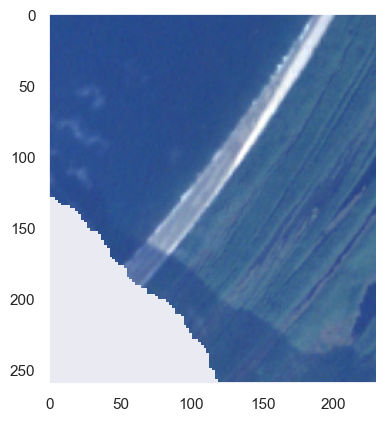

In [6]:
im_idx = 3
im_RGB = SDS_preprocess.rescale_image_intensity(ims[im_idx][:,:,[2,1,0]], cloud_masks[im_idx], 99.9)
print(fn_to_title(fns[im_idx][0], sitename))
plt.imshow(im_RGB)
plt.grid(False)

2002-08-29-19-37-16_L7_055022_mini-rose-spit


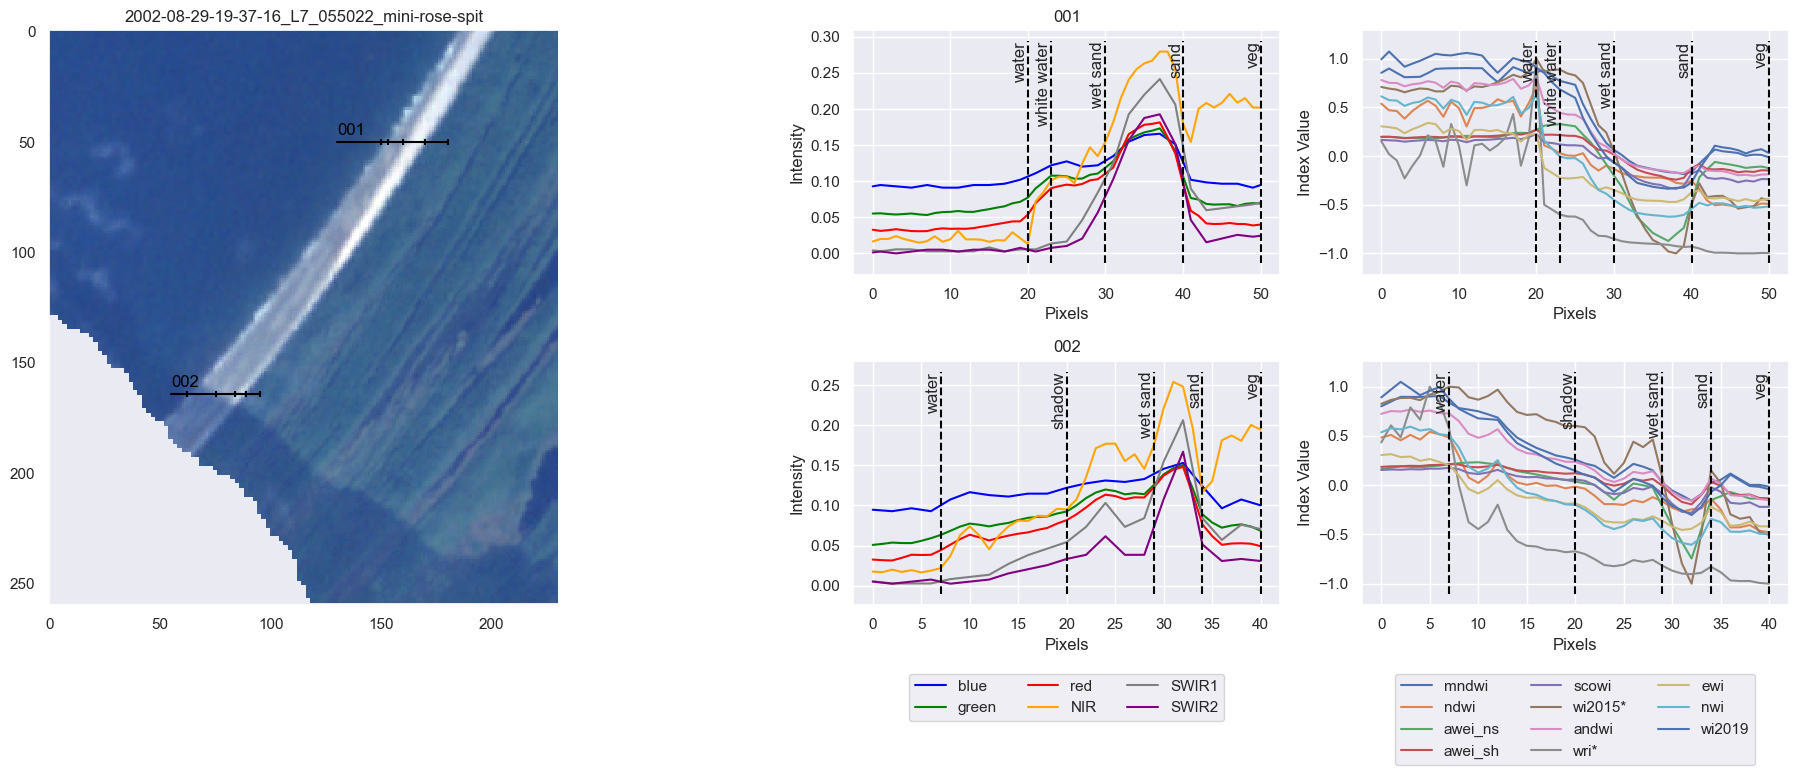

In [7]:
t, b_points, b_labs, sl_points, t_labs = get_image_plotting_params(sitename, im_idx)
title=fn_to_title(fns[im_idx][0], sitename)
samples = sample_ms(ims[im_idx], t)
print(title)
index_functions = [
    mndwi,
    ndwi,
    awei_ns,
    awei_sh,
    scowi,
    wi2015,
    andwi,
    wri,
    ewi,
    nwi,
    wi2019
]
plot_samples(ims[im_idx], title, cloud_masks[im_idx], t, samples, b_points, b_labs, t_labs, index_functions)

2002-08-29-19-37-16_L7_055022_mini-rose-spit


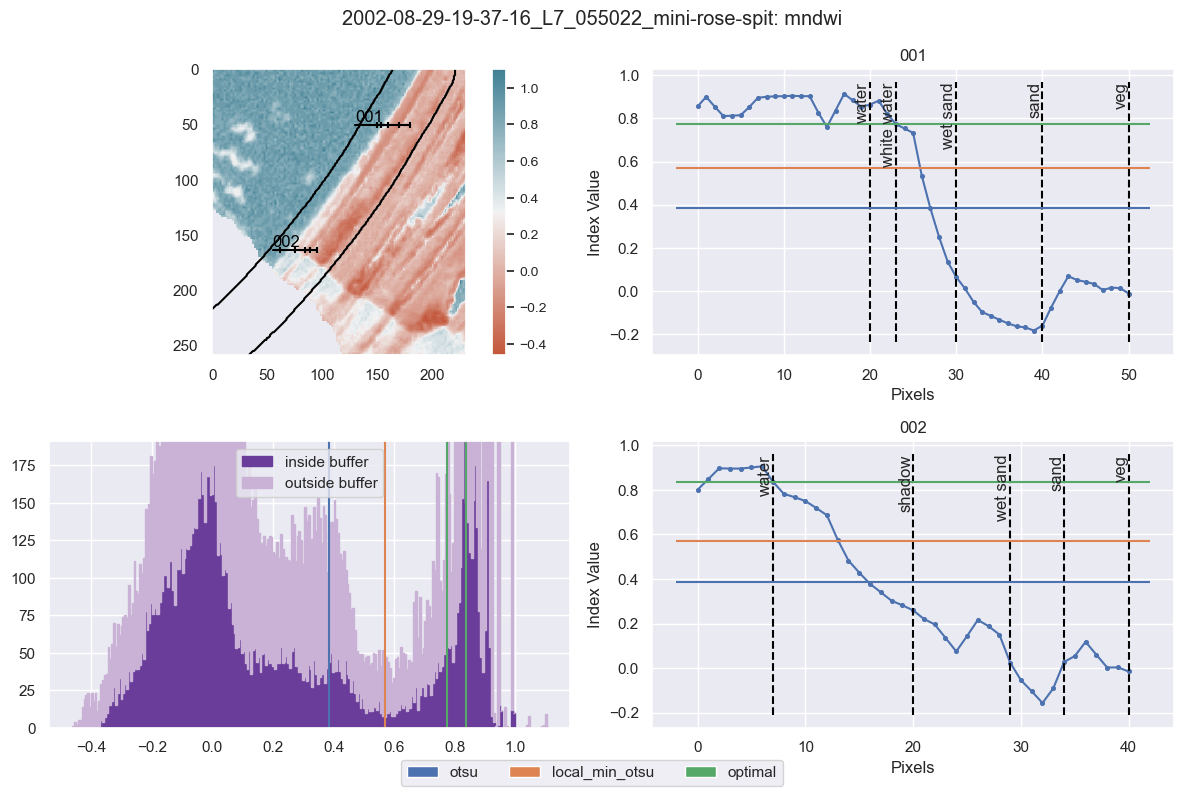

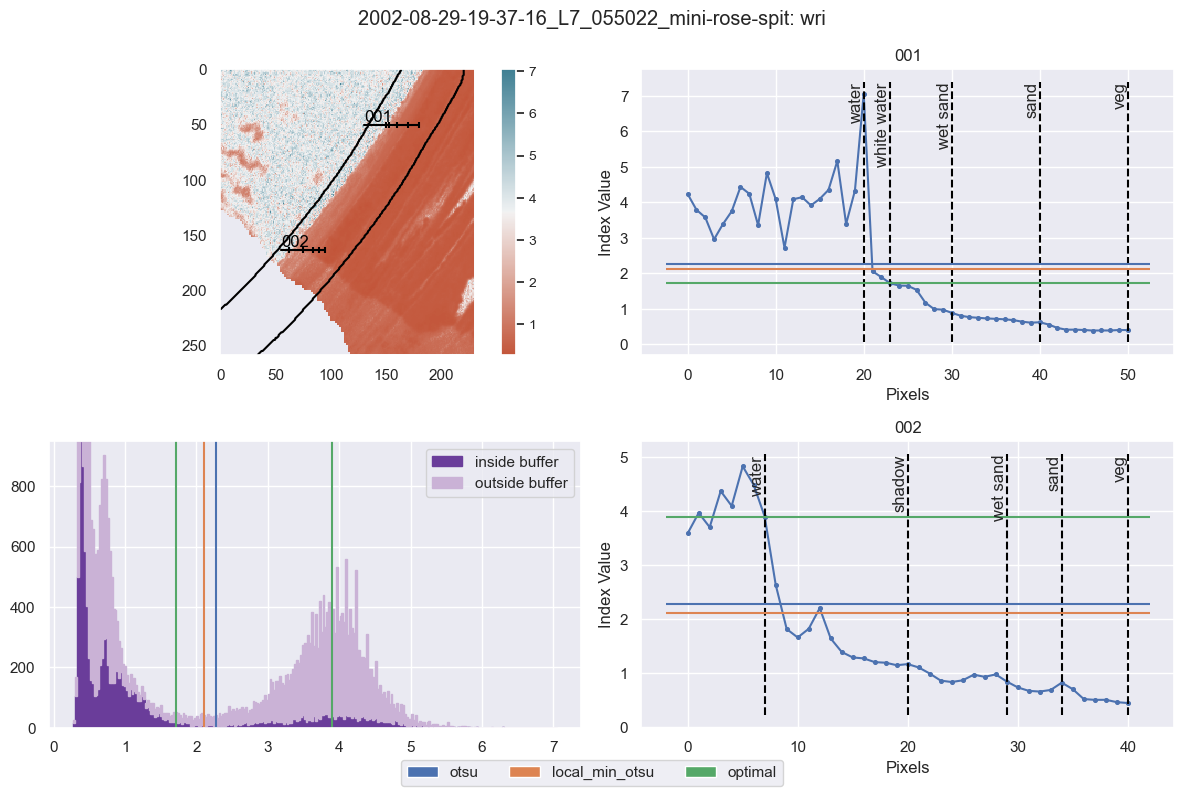

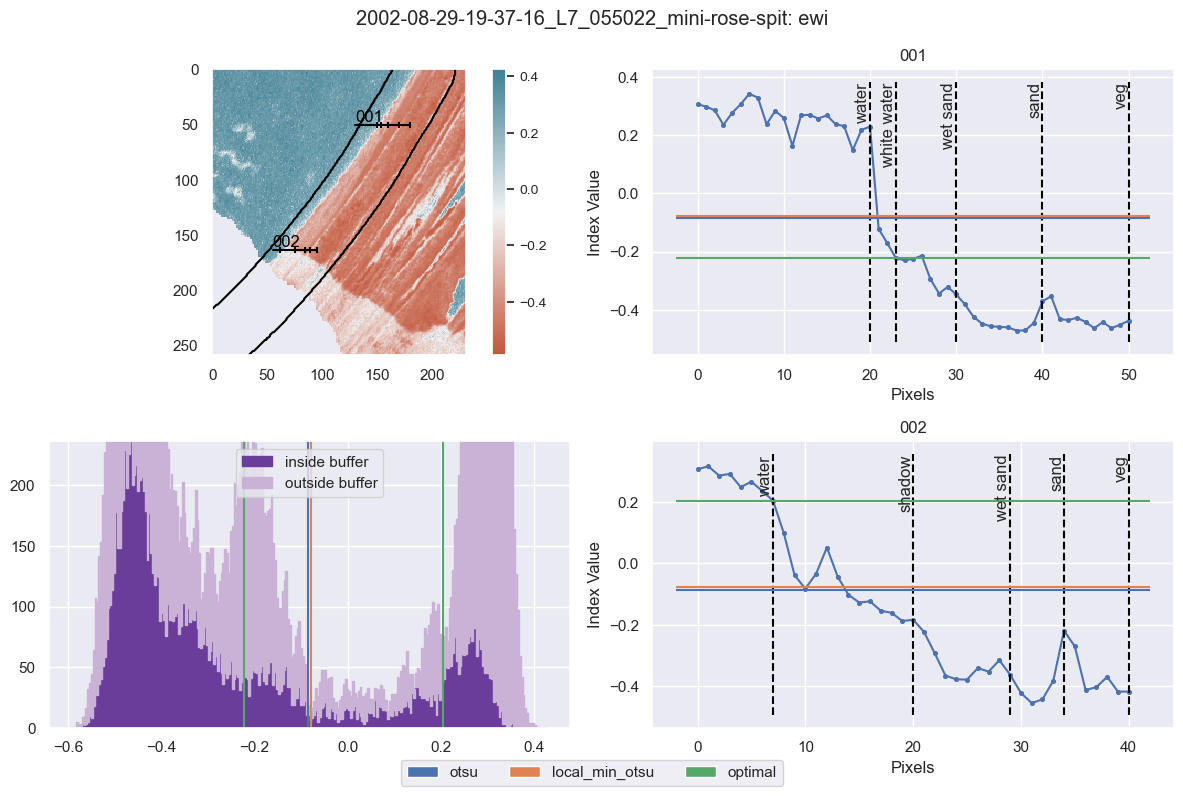

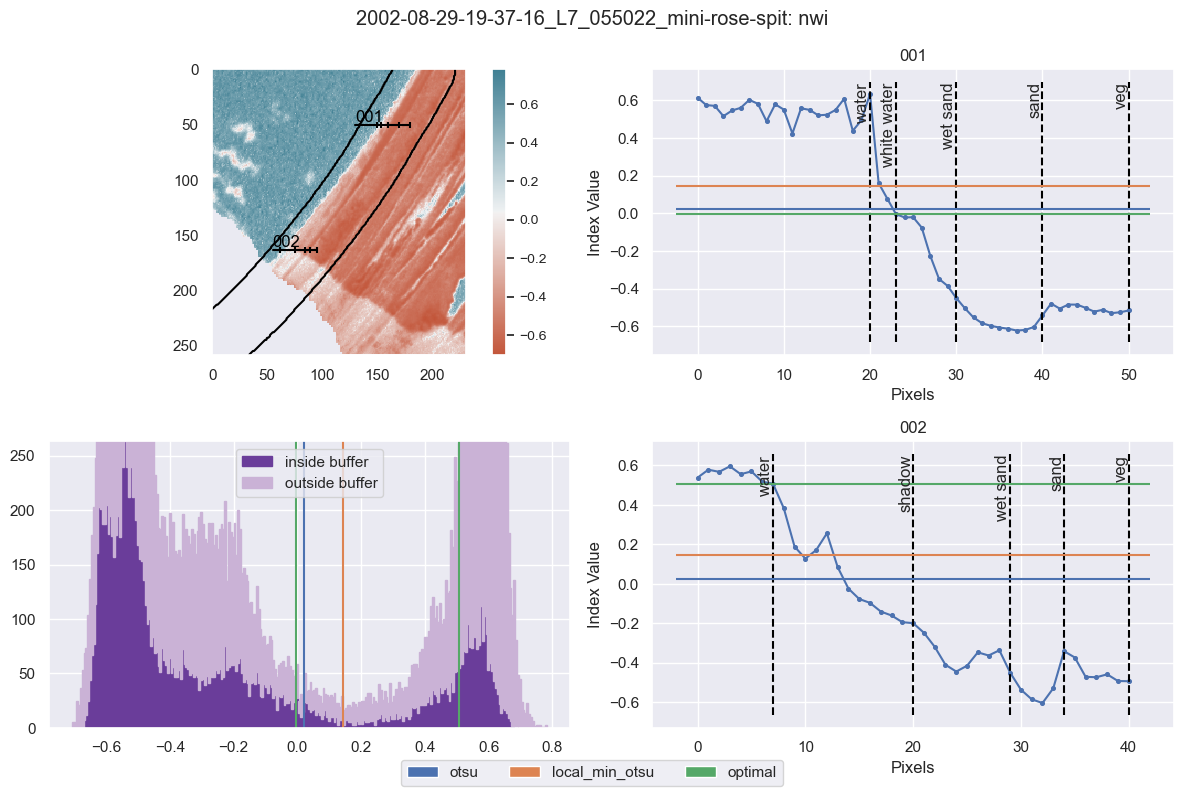

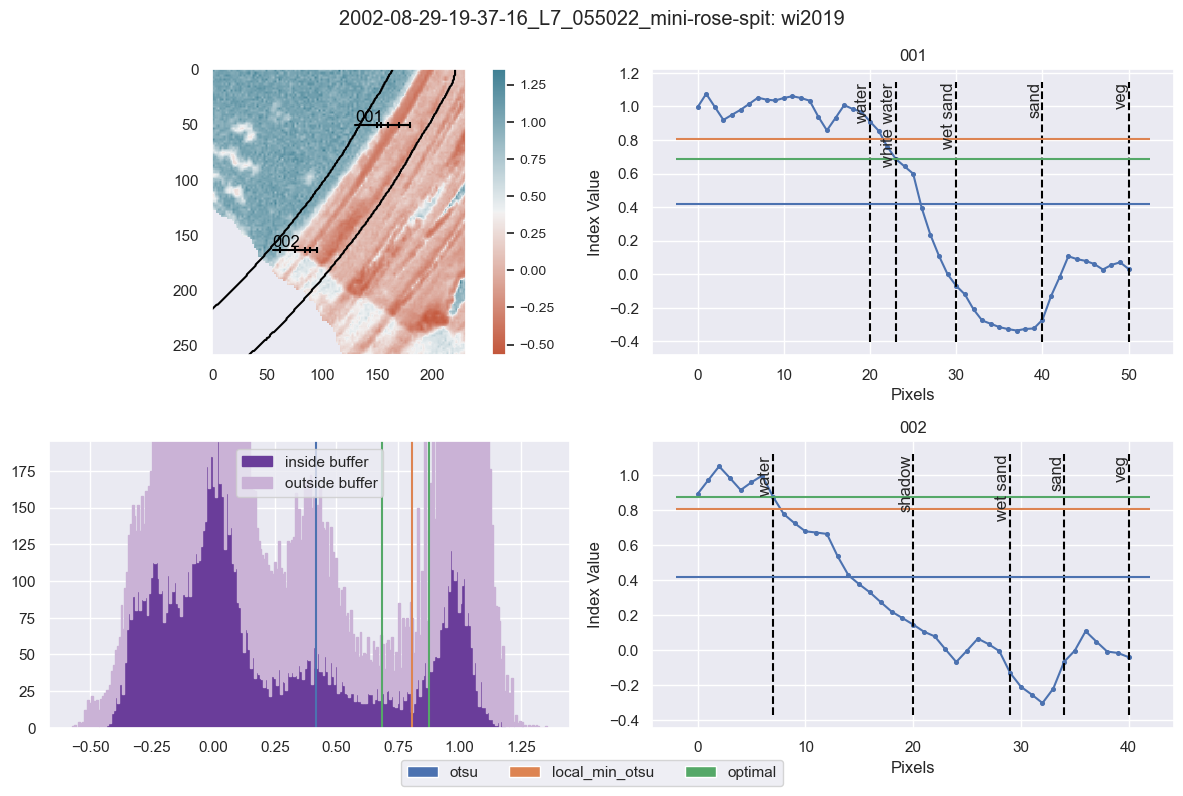

In [8]:
t, b_points, b_labs, sl_points, t_labs = get_image_plotting_params(sitename, im_idx)
title=fn_to_title(fns[im_idx][0], sitename)
samples = sample_ms(ims[im_idx], t)
print(title)

index_functions = [
    mndwi,
    # ndwi,
    # awei_ns,
    # awei_sh,
    # scowi,
    # wi2015,
    # andwi,
    wri,
    ewi,
    nwi,
    wi2019
]
threshold_functions = [
    otsu,
    local_min_otsu
]

plot_indices(
    im=ims[im_idx],
    title=title,
    samples=samples,
    transects=t,
    boundary_points=b_points,
    boundary_labels=b_labs,
    transect_labels=t_labs,
    shoreline_points=sl_points,
    cloud_mask=cloud_masks[im_idx],
    im_buffer=im_buffers[im_idx],
    ind_fns=index_functions,
    thresh_fns=threshold_functions
)

2002-08-29-19-37-16_L7_055022_mini-rose-spit


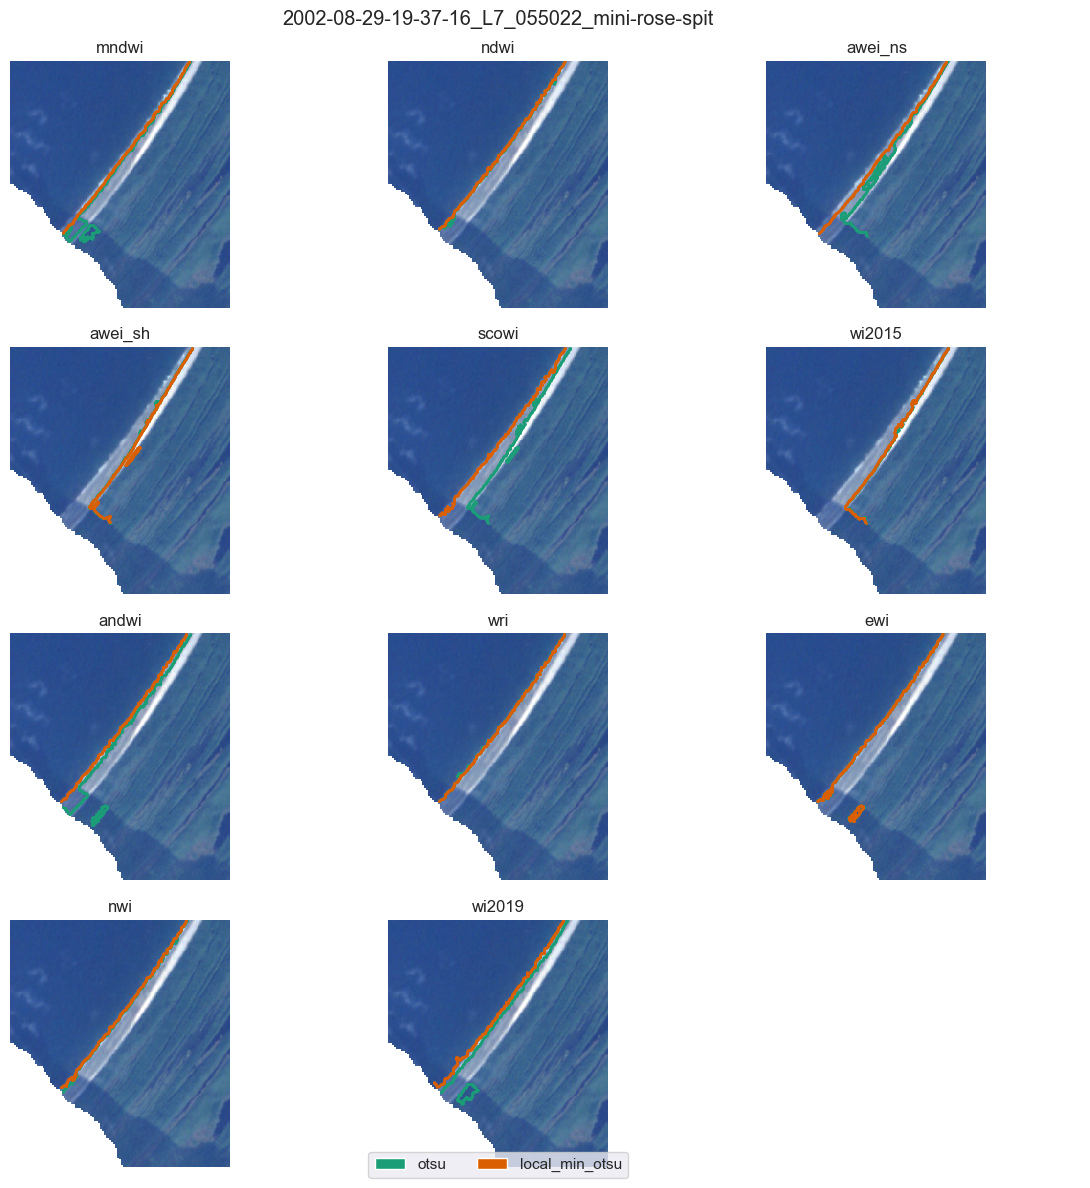

In [9]:
title=fn_to_title(fns[im_idx][0], sitename)
print(title)
index_functions = [
    mndwi,
    ndwi,
    awei_ns,
    awei_sh,
    scowi,
    wi2015,
    andwi,
    wri,
    ewi,
    nwi,
    wi2019
]
threshold_functions = [
    otsu,
    local_min_otsu
]
plot_extractions(
    ims[im_idx],
    title,
    index_functions,
    threshold_functions,
    cloud_masks[im_idx],
    im_buffers[im_idx],
    im_nodatas[im_idx],
    georefs[im_idx],
    im_epsgs[im_idx],
    buffer_settings
)

In [11]:
index_functions = [
    mndwi,
    ndwi,
    awei_ns,
    awei_sh,
    scowi,
    wi2015,
    andwi,
    wri,
    ewi,
    nwi,
    wi2019
]
threshold_functions = [
    otsu,
    local_min_otsu
]
save_all_plots(sitename, fns, ims, cloud_masks, im_buffers, im_nodatas, georefs, im_epsgs, index_functions, threshold_functions, buffer_settings, output_dir)